# K-Means Clustering  
K-Means clustering merupakan salah satu metode dalam unsupervised learning yang digunakan untuk mengelompokkan data ke dalam beberapa kelompok (cluster) berdasarkan kesamaan karakteristik atau fitur. Tujuan utamanya adalah untuk membagi data ke dalam K kelompok yang saling terpisah, dimana dalam kelompok data bersifat homogen dan antar kelompok data bersifat heterogen.  

## Langkah-langkah algoritma K-Means :  
1. Menentukan jumlah kluster sebanyak $K$  
* Artinya menentukan berapa banyak kelompok/kluster yang ingin dibuat dari data. Misalnya $K$ = 3 maka membagi data menjadi 3 kluster. 
* Pemilihan nilai $K$ dapat menggunakan metode seperti Elbow Method untuk membantu menentukan $K$ yang optimal.   
2. Memilih K centroid awal secara acak  
* Artinya menentukan titik awal (centroid) sebagai pusat dari masing-masing kluster.  
* Centroid bisa dipilih secara acak dari data yang ada atau menggunakan teknik seperti K-Means++ dimana dijalankan secara otomatis pada scikit-learn untuk hasil centroid yang lebih baik.  
3. Menghitung jarak setiap data ke tiap centroid  
* Artinya menentukan seberapa dekat setiap data ke setiap centroid.
* Umumnya menggunakan Euclidian distance.
4. Mengelompokkan data berdasarkan centroid terdekat  
* Artinya mengklasifikasikan setiap data ke dalam salah satu dari $K$ kluster.  
* Setiap data ditempatkan ke kluster yang pusatnya (centroid-nya) paling dekat dengannya. Jadi, tiap data hanya masuk ke satu kluster. 
5. Menghitung rata-rata dari anggota kluster, untuk menemukan centroid baru
* Menentukan pusat kluster baru berdasarkan data yang saat ini berada dalam kluster tersebut.  
* Centroid baru adalah rata-rata dari semua data di dalam suatu kluster. 
6. Mengulang langkah nomor 3-5 sampai data pada setiap kluster tidak berubah signifikan.  
* Iterasi dilakukan sampai tidak ada lagi data yang berpindah kluster, atau perubahan posisi centroid sangat kecil.  

## Evaluasi Hasil K-Means  
1. Inertia (Sum Square Error/SSE)  
Inertia mengukur sejauh mana titik data dalam suatu cluster tersebar dari pusat cluster tersebut. Semakin kecil nilai inertia, klaster semakin baik.  

$$Inertia= \sum_{i=1}^{n} \left\| x_i - \mu_{c_i} \right\|^2$$  

**Keterangan** :   
$x_i$ : Titik data ke-$i$  
$\mu_{c_i}$ : Centroid dari cluster tempat $x_i$ berada  

* Nilai inertia (sangat kecil/mendekati 0) : Klaster sangat kompak dan semua titik dekat dengan centroidnya (**sangat baik**).  
* Nilai inertia (kecil-sedang) : Klaster cukup baik dan dapat diterima dalam banyak kasus.  
* Nilai inertia (besar) : Klaster tidak rapat,  data menyebar jauh dari centroid → bisa jadi jumlah klaster (k) kurang tepat atau K-Means tidak cocok digunakan.



2. Silhouette Method : Sebuah metode yang mengukur tingkat kemiripan suatu point dengan clusternya dibandingkan dengan kluster lain.  

* untuk setiap titik $i$, silhouette ($i$) dihitung sebagai :   

$$s(i) = \frac{b(i) - a(i)}{\max\{a(i), b(i)\}}$$  

**Keterangan** :  
$a(i)$ : rata-rata jarak titik $i$ ke semua titik lain dalam klaster yang sama.  
$b(i)$ : rata-rata jarak titik $i$ ke semua titik dalam klaster terdekat (tetangga).

* Nilai silhouette mendekati angka 1 artinya suatu data berada pada cluster yang benar dengan jarak jauh dari cluster lain. 
* Nilai silhouette negatif artinya data tersebut lebih baik berada di kluster lain daripada kluster saat ini.
* Nilai silhouette = 0, artinya data tersebut di perbatasan antara dua cluster.  



## Komputasi K-Means Data IRIS

###  2 Klaster

In [1]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import silhouette_score, accuracy_score, confusion_matrix
import pandas as pd

# Baca data fitur dan label
df_features = pd.read_excel("data_iris.xlsx")
df_class = pd.read_excel("class.xlsx")  # kolom 'class'

df = df_features.copy()
df['class'] = df_class['class']

# Ambil fitur untuk clustering
features = df[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']]

# Normalisasi fitur(MinMax)
scaler = MinMaxScaler()
scaled_features = scaler.fit_transform(features)

# KMeans clustering
K = 2
kmeans = KMeans(n_clusters=K, max_iter=300, tol=0.0001, random_state=42, n_init='auto')
kmeans.fit(scaled_features)

df['cluster'] = kmeans.labels_

print(f"Jumlah iterasi sampai konvergen: {kmeans.n_iter_}")
print(f"Inertia (SSE): {kmeans.inertia_:.4f}")
sil_score = silhouette_score(scaled_features, kmeans.labels_)
print(f"Silhouette Score: {sil_score:.4f}")

# Mapping cluster ke class mayoritas
mapping = (
    df.groupby('cluster')['class']
    .agg(lambda x: x.mode()[0])
    .to_dict()
)
df['predicted_class'] = df['cluster'].map(mapping)

# Evaluasi
y_true = df['class']
y_pred = df['predicted_class']

acc = accuracy_score(y_true, y_pred)
print(f"\nAkurasi keseluruhan clustering terhadap label asli: {acc:.4%}")

# Distribusi cluster per kelas (untuk insight)
dist = pd.crosstab(df['class'], df['cluster'], rownames=['Class'], colnames=['Cluster'])
print("\nDistribusi cluster per kelas:")
print(dist)

# Simpan hasil ke Excel
df.to_excel("hasil2.xlsx", index=False)

# Kalau ingin tampil semua baris (hati-hati jika data sangat banyak)
pd.set_option('display.max_rows', None)
print(df[['class', 'cluster', 'predicted_class']])



Jumlah iterasi sampai konvergen: 4
Inertia (SSE): 12.1437
Silhouette Score: 0.6295

Akurasi keseluruhan clustering terhadap label asli: 66.6667%

Distribusi cluster per kelas:
Cluster           0   1
Class                  
Iris-setosa       0  50
Iris-versicolor  50   0
Iris-virginica   50   0
               class  cluster  predicted_class
0        Iris-setosa        1      Iris-setosa
1        Iris-setosa        1      Iris-setosa
2        Iris-setosa        1      Iris-setosa
3        Iris-setosa        1      Iris-setosa
4        Iris-setosa        1      Iris-setosa
5        Iris-setosa        1      Iris-setosa
6        Iris-setosa        1      Iris-setosa
7        Iris-setosa        1      Iris-setosa
8        Iris-setosa        1      Iris-setosa
9        Iris-setosa        1      Iris-setosa
10       Iris-setosa        1      Iris-setosa
11       Iris-setosa        1      Iris-setosa
12       Iris-setosa        1      Iris-setosa
13       Iris-setosa        1      Iris-setosa

###  3 Klaster

In [4]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import silhouette_score, accuracy_score, confusion_matrix
import pandas as pd

# Baca data fitur dan label
df_features = pd.read_excel("data_iris.xlsx")
df_class    = pd.read_excel("class.xlsx")  # kolom 'class'

df = df_features.copy()
df['class'] = df_class['class']

# Ambil fitur untuk clustering
features = df[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']]

# Normalisasi fitur (MinMax)
scaler = MinMaxScaler()
scaled_features = scaler.fit_transform(features)

# KMeans clustering
K = 3
kmeans = KMeans(
    n_clusters=K,
    max_iter=300,
    tol=0.0001,
    random_state=42,
    n_init='auto'  # ganti ke 10 jika sklearn <1.4
)
kmeans.fit(scaled_features)
df['cluster'] = kmeans.labels_

# Cetak metrik clustering
print(f"Jumlah iterasi sampai konvergen: {kmeans.n_iter_}")
print(f"Inertia (SSE): {kmeans.inertia_:.4f}")
sil_score = silhouette_score(scaled_features, kmeans.labels_)
print(f"Silhouette Score: {sil_score:.4f}")

# Mapping cluster ke class mayoritas
mapping = (
    df.groupby('cluster')['class']
      .agg(lambda x: x.mode()[0])
      .to_dict()
)
df['predicted_class'] = df['cluster'].map(mapping)

# Siapkan untuk evaluasi
y_true   = df['class']
y_pred   = df['predicted_class']
classes  = sorted(df['class'].unique())
cm       = confusion_matrix(y_true, y_pred, labels=classes)

# Akurasi keseluruhan
acc = accuracy_score(y_true, y_pred)
print(f"\nAkurasi keseluruhan clustering terhadap label asli: {acc:.4%}")

# Persentase error per kelas
error_per_class = {}
for i, c in enumerate(classes):
    total   = cm[i].sum()
    correct = cm[i, i]
    error   = 1 - correct/total if total > 0 else 0
    error_per_class[c] = error

print("\nPersentase kesalahan per kelas:")
for c, e in error_per_class.items():
    print(f" - {c}: {e:.2%}")

# Distribusi cluster per kelas (insight)
dist = pd.crosstab(df['class'], df['cluster'], 
                   rownames=['Class'], colnames=['Cluster'])
print("\nDistribusi cluster per kelas:")
print(dist)

# Simpan hasil lengkap ke Excel
df.to_excel("hasil_clustering_dengan_class_lengkap.xlsx", index=False)

# Tampilkan perbandingan class vs cluster vs predicted_class
pd.set_option('display.max_rows', None)
print("\nPerbandingan lengkap:")
print(df[['class', 'cluster', 'predicted_class']])

Jumlah iterasi sampai konvergen: 3
Inertia (SSE): 7.1386
Silhouette Score: 0.4825

Akurasi keseluruhan clustering terhadap label asli: 88.0000%

Persentase kesalahan per kelas:
 - Iris-setosa: 0.00%
 - Iris-versicolor: 20.00%
 - Iris-virginica: 16.00%

Distribusi cluster per kelas:
Cluster           0   1   2
Class                      
Iris-setosa       0  50   0
Iris-versicolor  10   0  40
Iris-virginica   42   0   8

Perbandingan lengkap:
               class  cluster  predicted_class
0        Iris-setosa        1      Iris-setosa
1        Iris-setosa        1      Iris-setosa
2        Iris-setosa        1      Iris-setosa
3        Iris-setosa        1      Iris-setosa
4        Iris-setosa        1      Iris-setosa
5        Iris-setosa        1      Iris-setosa
6        Iris-setosa        1      Iris-setosa
7        Iris-setosa        1      Iris-setosa
8        Iris-setosa        1      Iris-setosa
9        Iris-setosa        1      Iris-setosa
10       Iris-setosa        1      Ir

### 4 Klaster

In [5]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import silhouette_score, accuracy_score, confusion_matrix
import pandas as pd

# Baca data fitur dan label
df_features = pd.read_excel("data_iris.xlsx")
df_class = pd.read_excel("class.xlsx")  # kolom 'class'

df = df_features.copy()
df['class'] = df_class['class']

# Ambil fitur untuk clustering
features = df[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']]

# Normalisasi fitur(MinMax)
scaler = MinMaxScaler()
scaled_features = scaler.fit_transform(features)

# KMeans clustering
K = 4
kmeans = KMeans(n_clusters=K, max_iter=300, tol=0.0001, random_state=42, n_init='auto')
kmeans.fit(scaled_features)

df['cluster'] = kmeans.labels_

print(f"Jumlah iterasi sampai konvergen: {kmeans.n_iter_}")
print(f"Inertia (SSE): {kmeans.inertia_:.4f}")
sil_score = silhouette_score(scaled_features, kmeans.labels_)
print(f"Silhouette Score: {sil_score:.4f}")

# Mapping cluster ke class mayoritas
mapping = (
    df.groupby('cluster')['class']
    .agg(lambda x: x.mode()[0])
    .to_dict()
)
df['predicted_class'] = df['cluster'].map(mapping)

# Evaluasi
y_true = df['class']
y_pred = df['predicted_class']

acc = accuracy_score(y_true, y_pred)
print(f"\nAkurasi keseluruhan clustering terhadap label asli: {acc:.4%}")

# Distribusi cluster per kelas (untuk insight)
dist = pd.crosstab(df['class'], df['cluster'], rownames=['Class'], colnames=['Cluster'])
print("\nDistribusi cluster per kelas:")
print(dist)

# Simpan hasil ke Excel
df.to_excel("hasil4.xlsx", index=False)

# Kalau ingin tampil semua baris (hati-hati jika data sangat banyak)
pd.set_option('display.max_rows', None)
print(df[['class', 'cluster', 'predicted_class']])



Jumlah iterasi sampai konvergen: 6
Inertia (SSE): 5.5417
Silhouette Score: 0.4435

Akurasi keseluruhan clustering terhadap label asli: 84.6667%

Distribusi cluster per kelas:
Cluster           0   1   2   3
Class                          
Iris-setosa       0  50   0   0
Iris-versicolor  21   0  29   0
Iris-virginica   21   0   2  27
               class  cluster  predicted_class
0        Iris-setosa        1      Iris-setosa
1        Iris-setosa        1      Iris-setosa
2        Iris-setosa        1      Iris-setosa
3        Iris-setosa        1      Iris-setosa
4        Iris-setosa        1      Iris-setosa
5        Iris-setosa        1      Iris-setosa
6        Iris-setosa        1      Iris-setosa
7        Iris-setosa        1      Iris-setosa
8        Iris-setosa        1      Iris-setosa
9        Iris-setosa        1      Iris-setosa
10       Iris-setosa        1      Iris-setosa
11       Iris-setosa        1      Iris-setosa
12       Iris-setosa        1      Iris-setosa
13     

Kesimpulan :  
1. K = 2   
Inertia (SSE): 12.1437  
Silhouette Score: 0.6295

* Nilai skor inertia lebih besar dari yang lain dan nilai skor silhouette yang diperoleh adalah yang tertinggi dibandingkan dengan K lainnya (lebih mendekati 1).

2. K = 3  
Inertia (SSE): 7.1386  
Silhouette Score: 0.4825 

* Nilai skor inertia turun dan nilai skor silhouette juga mengalami penurunan dibandingkan dengan k=2 (menjauh dari 1).

3. K =4  
Inertia (SSE): 5.5417  
Silhouette Score: 0.4435

* Nilai skor inertia dan nilai skor silhouette sama-sama mengalami penurunan (semakin jauh dari 1).  

Maka berdasarkan hasil evaluasi yang telah dilakukan, nilai K = 2 merupakan jumlah klaster yang paling optimal. Hal ini ditunjukkan oleh nilai silhouette score paling mendekati 1 (0.6295).

### Metode Elbow 
Metode Elbow untuk menentukan jumlah klaster 𝑘 yang optimal dengan memantau penurunan nilai inertia seiring bertambahnya 𝑘. Titik sebelum grafik melandai adalah titik siku (elbow point) → yaitu jumlah klaster optimal.

Contoh Elbow Method :

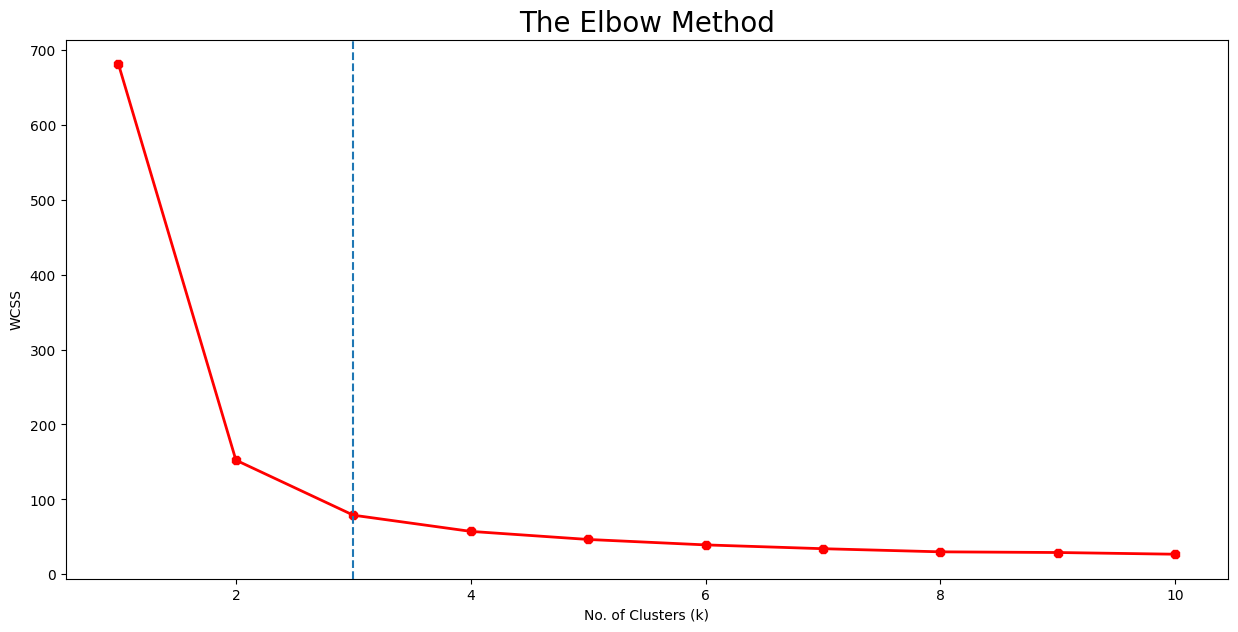

In [16]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler

iris = pd.read_excel('data_iris.xlsx')
iris_x = iris.iloc[:, 1:5]
iris_x.head()

x_iris = np.array(iris_x)
scaler = MinMaxScaler()
x_scaled = scaler.fit_transform(x_iris)
x_scaled

wcss=[]
for i in range(1,11):
    km = KMeans(i)
    km.fit(iris_x)
    wcss.append(km.inertia_)
np.array(wcss)

fig, ax = plt.subplots(figsize=(15,7))
ax = plt.plot(range(1,11),wcss, linewidth=2, color="red", marker ="8")
plt.axvline(x=3, ls='--')
plt.ylabel('WCSS')
plt.xlabel('No. of Clusters (k)')
plt.title('The Elbow Method', fontsize = 20)
plt.show()

* Berdasarkan metode Elbow, jumlah klaster optimal adalah K = 3, karena pada titik ini terjadi penurunan WCSS (Within-Cluster Sum of Squares) yang signifikan sebelum grafik mulai melandai.